# 01 · Les données : d'où elles viennent, et ce qu'elles valent

**Bloc 5 · W37 — mini-projet éCO2mix, notebook 1 sur 4.**

> **Objectif métier.** Supprimer les arbitrages manuels du comité de pilotage en livrant un jeu unique de
> prévisions de consommation électrique dont **la somme des régions reproduit exactement le total France**,
> sans retouche.

Avant de prévoir quoi que ce soit, ce notebook vérifie que les données permettent de répondre à cette
question. Chaque contrôle est une hypothèse explicite, testée sur les données.

| § | Contenu | Question |
|---|---|---|
| 1 | Provenance | De quelles données exactement vient chaque chiffre ? |
| 2 | La hiérarchie | Quelles séries, quelle matrice S ? |
| 3 | Le défaut de changement d'heure | Les séries sont-elles complètes et sans doublon ? |
| 4 | 30 min → 1 h | Comment agréger sans changer d'unité ? |
| 5 | 🔬 L'additivité | Le total France officiel est-il vraiment la somme des 12 régions ? |
| 6 | Les saisonnalités | Que doit capturer un modèle de base ? |
| 7 | Corrélations entre régions | Pourquoi MinT a-t-il quelque chose à exploiter ? |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.eco2mix import run, prepare, source, metrics, inference, figures

viz.setup()
pd.set_option("display.precision", 3)
cfg, paths = run.load_config()
if not (paths.interim / "hourly_regions.parquet").exists():
    raise FileNotFoundError("Données absentes : lancer d'abord `uv run w37 eco2mix download` puis `prepare`.")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

## 1. Provenance : un manifeste pour chaque fichier

Les données viennent de l'API d'**Open Data Réseaux Énergies (ODRÉ)**, publiées par RTE sous Licence Ouverte v2.0.
`w37 eco2mix download` écrit les fichiers bruts **tels que l'API les renvoie**, puis un manifeste : URL exacte,
date, taille, nombre de lignes, empreinte sha256. Les étapes suivantes refusent de tourner si un fichier brut a
été modifié depuis.

💡 **Pourquoi c'est important.** Un chiffre publié doit pouvoir être rejoué. Sans le manifeste, « les données
éCO2mix » ne veut rien dire : le jeu est rafraîchi tous les jours, et les données récentes sont révisées.

In [2]:
manifest = json.loads((paths.raw / "manifest.json").read_text())
tab = pd.DataFrame(manifest["files"]).T
tab = pd.DataFrame({"lignes": tab["rows"].astype(int), "Mo": tab["bytes"].astype(float) / 1e6,
                    "sha256": tab["sha256"].str[:12] + "…", "téléchargé le": tab["downloaded_at"]})
display(tab.style.format({"lignes": "{:,}", "Mo": "{:.1f}"}))
bad = source.verify(paths.raw)
print("Intégrité des fichiers bruts :", "OK, sha256 identiques au manifeste" if not bad else f"MODIFIÉS : {bad}")
print("Attribution :", manifest["attribution"])

,lignes,Mo,sha256,téléchargé le
regional_11.csv,"210,382",10.6,a974d8d14852…,2026-10-02T22:06:08+00:00
regional_24.csv,"210,382",11.6,8bc3c519672e…,2026-10-02T22:06:29+00:00
regional_27.csv,"210,382",12.6,88fc5b481136…,2026-10-02T22:06:49+00:00
regional_28.csv,"210,382",9.5,38c2207e5cc3…,2026-10-02T22:07:10+00:00
regional_32.csv,"210,382",10.7,0b8d96858607…,2026-10-02T22:07:27+00:00
regional_44.csv,"210,382",9.5,a5bc44f8a3bb…,2026-10-02T22:07:47+00:00
regional_52.csv,"210,382",10.9,1d58fbc79e1c…,2026-10-02T22:08:08+00:00
regional_53.csv,"210,382",9.3,3ddcd62ffbe9…,2026-10-02T22:08:25+00:00
regional_75.csv,"210,382",11.4,4251316b8603…,2026-10-02T22:08:45+00:00
regional_76.csv,"210,382",9.5,dcebd3a1d10f…,2026-10-02T22:09:04+00:00


Intégrité des fichiers bruts : OK, sha256 identiques au manifeste
Attribution : Open Data Réseaux Énergies (ODRÉ) — RTE, Licence Ouverte v2.0


⚠️ **Point d'attention — le jeu n'est pas homogène dans le temps.** En interrogeant l'API (le 02/10/2026, 22 h UTC), on
découvre que la **Nouvelle-Aquitaine s'arrête au 31/12/2024**, alors que les 11 autres régions continuent
jusqu'au 30/06/2026. La rupture coïncide avec le passage des données « définitives » aux données
« consolidées ». Depuis 2025, la somme des régions disponibles **n'est plus** le total France.

C'est exactement le type de changement de hiérarchie que le contrôle `hash_check` du bloc 3 doit bloquer. Ici,
on le traite à la source : le protocole (`configs/eco2mix.yaml`) se limite aux **données définitives,
2013 → 2024**, où les 12 régions sont présentes.

## 2. La hiérarchie : 12 régions, 1 total

La structure est la plus simple qui soit : un niveau « France » et 12 feuilles. La matrice S a 13 lignes
(1 total + 12 régions) et 12 colonnes. Pas de nomenclature produit à négocier, pas de doublons : S est
incontestable, ce qui permet de se concentrer sur la réconciliation elle-même.

Le total France est **construit** comme la somme des 12 régions. Il est donc cohérent par définition, et le
§ 5 vérifie qu'il coïncide avec le total officiel publié par RTE.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


S : 13 séries × 12 feuilles ; première ligne (France) = [1 1 1 1 1 1 1 1 1 1 1 1]


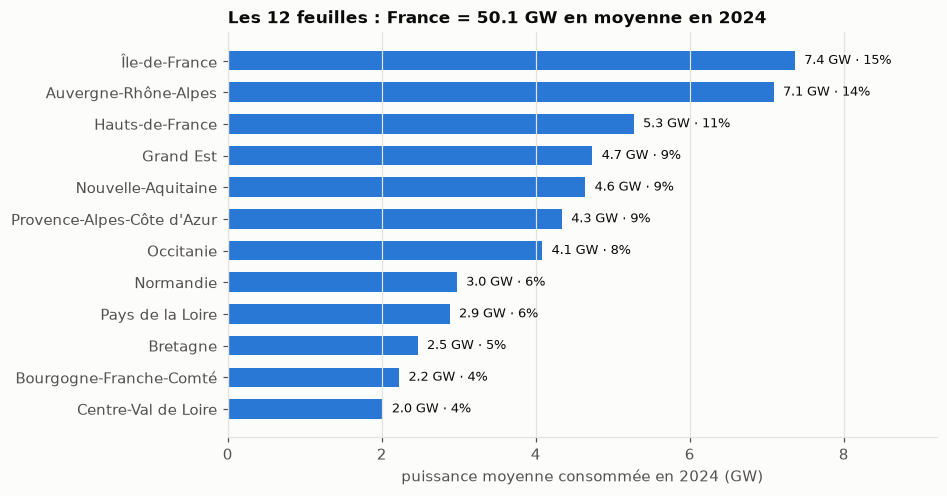

plus grosse / plus petite région : 3.7


In [3]:
hier = run.load_hierarchy(cfg, paths)
print(f"S : {hier.S.shape[0]} séries × {hier.S.shape[1]} feuilles ; première ligne (France) = {hier.S[0].astype(int)}")
hourly = pd.read_parquet(paths.interim / "hourly_regions.parquet")
y24 = hourly[hourly["ds"].dt.year == 2024].groupby("region")["y"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.4), layout="constrained")
ax.barh(y24.index, y24.to_numpy() / 1000, color=viz.BLUE, height=0.62)
for i, v in enumerate(y24.to_numpy()):
    ax.text(v / 1000 + 0.12, i, f"{v / 1000:.1f} GW · {v / y24.sum():.0%}", va="center", fontsize=8.5)
ax.set_xlabel("puissance moyenne consommée en 2024 (GW)")
ax.set_xlim(0, y24.max() / 1000 * 1.25)
ax.grid(axis="y", visible=False)
ax.set_title(f"Les 12 feuilles : France = {y24.sum() / 1000:.1f} GW en moyenne en 2024")
export(fig, "regions_2024"); plt.show()
print(f"plus grosse / plus petite région : {y24.max() / y24.min():.1f}")

💡 **Ce que la figure annonce pour la suite.** La plus grosse région consomme plusieurs fois la plus petite
(rapport affiché ci-dessous). Les erreurs de prévision suivent les volumes : 1 % d'erreur sur l'Île-de-France
pèse bien plus que 1 % sur la Bretagne. C'est pourquoi le MASE, qui divise par une échelle propre à chaque série,
sert à comparer les régions entre elles.

## 3. Contrôle qualité : le défaut de changement d'heure

Les horodatages de l'API sont en UTC. En les comptant, deux anomalies apparaissent **chaque année, à la même
date, dans toutes les régions** :

| Date | Heure légale | Ce que contient la source | Conséquence en UTC |
|---|---|---|---|
| dernier dimanche de mars | 02:00 → 03:00 n'existe pas | une ligne pour 02:00 et 02:30 quand même | **2 instants en double** à 01:00 et 01:30 UTC |
| dernier dimanche d'octobre | 02:00 → 03:00 a lieu deux fois | une seule fois | **1 heure manquante** à 00:00 UTC |

💡 **L'explication.** La source range **48 demi-heures par jour local**, quel que soit le nombre réel de
demi-heures ce jour-là (46 en mars, 50 en octobre). La conversion en UTC fait alors apparaître des doublons au
printemps et un trou à l'automne.

In [4]:
raw = prepare.read_regional(paths.raw)
bzh = raw[raw["region"] == "Bretagne"].sort_values("ds")
mars = bzh[bzh["ds"].between("2024-03-31 00:00", "2024-03-31 02:30")]
octo = bzh[bzh["ds"].between("2024-10-26 23:00", "2024-10-27 02:00")]
display(Markdown("**Bretagne, 31 mars 2024 (UTC)** : 01:00 et 01:30 apparaissent deux fois"), mars[["ds", "y"]])
display(Markdown("**Bretagne, 27 octobre 2024 (UTC)** : 00:00 et 00:30 sont absents"), octo[["ds", "y"]])

**Bretagne, 31 mars 2024 (UTC)** : 01:00 et 01:30 apparaissent deux fois

,ds,y
1485919,2024-03-31 00:00:00,2475
1485918,2024-03-31 00:30:00,2372
1485916,2024-03-31 01:00:00,2460
1485917,2024-03-31 01:00:00,2460
1485914,2024-03-31 01:30:00,2424
1485915,2024-03-31 01:30:00,2424
1485913,2024-03-31 02:00:00,2276
1485912,2024-03-31 02:30:00,2197


**Bretagne, 27 octobre 2024 (UTC)** : 00:00 et 00:30 sont absents

,ds,y
1475839,2024-10-26 23:00:00,2121
1475838,2024-10-26 23:30:00,2015
1475837,2024-10-27 01:00:00,2079
1475836,2024-10-27 01:30:00,1978
1475835,2024-10-27 02:00:00,1756


In [5]:
quality = pd.read_csv(paths.interim / "quality.csv", index_col=0)
display(quality.rename(columns={"rows": "lignes brutes", "duplicates_identical": "doublons identiques",
                                "duplicates_conflicting": "doublons divergents",
                                "missing_halfhours": "demi-heures absentes", "missing_values": "valeurs vides",
                                "imputed_hours": "heures imputées", "longest_gap_hours": "plus long trou (h)"}))

,lignes brutes,doublons identiques,doublons divergents,demi-heures absentes,valeurs vides,heures imputées,plus long trou (h)
Auvergne-Rhône-Alpes,210382,16,8,24,0,12,1
Bourgogne-Franche-Comté,210382,15,9,24,0,12,1
Bretagne,210382,16,8,24,0,12,1
Centre-Val de Loire,210382,16,8,24,0,12,1
Grand Est,210382,16,8,24,0,12,1
Hauts-de-France,210382,16,8,24,0,12,1
Normandie,210382,16,8,24,0,12,1
Nouvelle-Aquitaine,210382,16,8,24,0,12,1
Occitanie,210382,17,7,24,0,12,1
Pays de la Loire,210382,16,8,24,0,12,1


Les comptes sont identiques d'une région à l'autre : **12 heures imputées** (une par mois d'octobre, de 2013 à 2024)
et **24 doublons** (deux par mois de mars). C'est la signature d'un défaut systématique de la source, pas d'un
incident de mesure.

**La règle appliquée** (`prepare.py`, testée dans `tests/unit/test_eco2mix.py`) :

1. on retire les doublons ; quand les deux valeurs diffèrent (7 à 9 cas sur 24 selon la région), on prend leur moyenne ;
2. on bouche l'heure manquante d'octobre par **interpolation linéaire** entre 23:00 et 01:00 UTC, et on la marque ;
3. un trou de plus d'une heure lève une **erreur** : on ne fabrique pas de données en silence.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


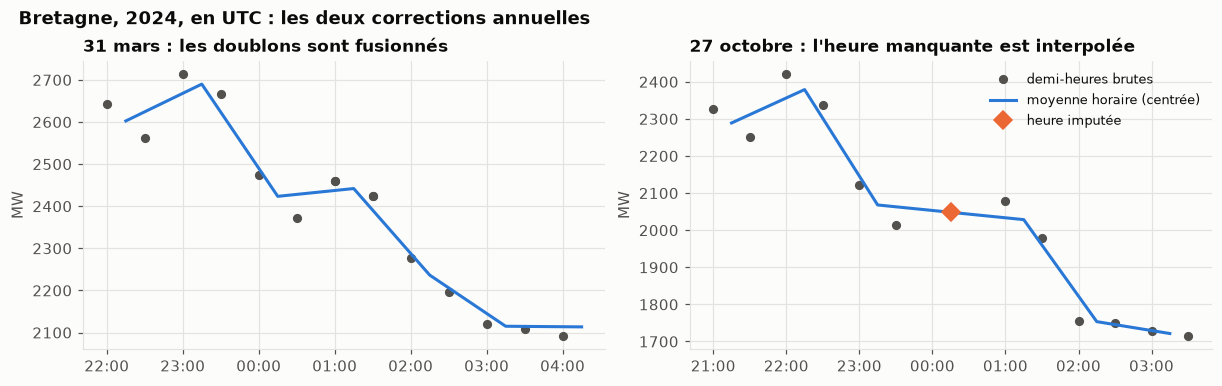

In [6]:
mask = pd.read_parquet(paths.interim / "imputed_mask.parquet")
h = hourly[hourly["region"] == "Bretagne"].set_index("ds")["y"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
for ax, (start, end, title) in zip(axes, [
        ("2024-03-30 22:00", "2024-03-31 04:00", "31 mars : les doublons sont fusionnés"),
        ("2024-10-26 21:00", "2024-10-27 03:30", "27 octobre : l'heure manquante est interpolée")]):
    r = bzh[bzh["ds"].between(start, end)]
    ax.plot(r["ds"], r["y"], "o", color=viz.TEXT_2, ms=5, label="demi-heures brutes")
    hh = h[start:end]
    ax.plot(hh.index + pd.Timedelta(minutes=15), hh.to_numpy(), "-", color=viz.BLUE, lw=2,
            label="moyenne horaire (centrée)")
    imp = hh[mask["Bretagne"].reindex(hh.index, fill_value=False)]
    ax.plot(imp.index + pd.Timedelta(minutes=15), imp.to_numpy(), "D", color=viz.ORANGE, ms=8,
            label="heure imputée")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_title(title); ax.set_ylabel("MW")
axes[1].legend(loc="upper right", fontsize=8.5)
fig.suptitle("Bretagne, 2024, en UTC : les deux corrections annuelles", x=0.01, ha="left", fontweight="semibold")
export(fig, "changement_heure"); plt.show()

⚠️ **Point d'attention — un trou ne fait pas toujours d'erreur.** Le plan prévient : *« un seul NaN dans une
feuille casse silencieusement la cohérence »*. En pratique, il y a deux cas, et un seul est bruyant :

- une **valeur vide** (NaN) : `aggregate` de HierarchicalForecast la refuse, et MSTL aussi (`mstl cannot handle
  missing values`). L'erreur est bruyante, mais elle ne parle pas de changement d'heure ;
- une **ligne absente** : `aggregate` ne dit rien, et le total de cette heure-là est calculé avec 11 régions.
  Il est faux de plusieurs GW, sans aucun message.

C'est pourquoi `assert_no_missing` vérifie aussi que toutes les séries ont **la même longueur et les mêmes
bornes** (test `test_a_missing_row_silently_breaks_the_total_and_is_caught`).

## 4. 30 min → 1 h : une moyenne, pas une somme

La consommation éCO2mix est une **puissance**, en MW : la puissance moyenne appelée sur la demi-heure. Pour
passer à l'heure, on prend la **moyenne** des deux demi-heures.

🧪 **Exemple.** 50 000 MW de 08:00 à 08:30 puis 52 000 MW de 08:30 à 09:00 :

In [7]:
ex = pd.Series([50_000.0, 52_000.0], index=pd.date_range("2024-11-05 08:00", periods=2, freq="30min"))
print(f"moyenne : {ex.resample('1h').mean().iat[0]:,.0f} MW  -> la puissance moyenne de l'heure")
print(f"somme   : {ex.resample('1h').sum().iat[0]:,.0f} « MW »  -> ni une puissance, ni une énergie")
print(f"énergie : {ex.mean() * 1:,.0f} MWh consommés sur l'heure (puissance moyenne × 1 h)")

moyenne : 51,000 MW  -> la puissance moyenne de l'heure
somme   : 102,000 « MW »  -> ni une puissance, ni une énergie
énergie : 51,000 MWh consommés sur l'heure (puissance moyenne × 1 h)


📌 **À retenir.** Agréger dans le **temps** (30 min → 1 h) se fait par la moyenne. Agréger dans l'**espace**
(régions → France) se fait par la somme : les puissances de régions disjointes s'additionnent. Ce sont deux
opérations différentes, et seule la seconde définit la hiérarchie.

## 5. 🔬 Test d'hypothèse : le total France est-il la somme des régions ?

Toute la réconciliation repose sur `y_France = Σ y_régions`. Si RTE publiait un total qui n'est pas la somme
(périmètre différent, pertes, Corse…), réconcilier vers ce total n'aurait pas de sens.

- **H0** : national officiel − Σ 12 régions = 0, à l'arrondi près.
- **Seuil** : chaque région est publiée arrondie au MW, donc l'écart dû à l'arrondi est d'au plus
  12 × 0,5 = **6 MW**.
- **Test** : on compare, heure par heure, le jeu national (téléchargé séparément) à la somme des régions, puis on
  regarde le pire écart **année par année**.

In [8]:
gap = pd.read_parquet(paths.interim / "additivity_gap.parquet")["national_moins_somme"]
tol = cfg["prepare"]["additivity_tol_mw"]
by_year = gap.abs().groupby(gap.index.year).agg(["median", "max"])
by_year.columns = ["|écart| médian (MW)", "|écart| max (MW)"]
by_year["H0 tenue (max ≤ 6 MW)"] = by_year["|écart| max (MW)"] <= tol
display(by_year.T)

ds,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
|écart| médian (MW),10.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
|écart| max (MW),14.0,4.0,2.5,215.0,3.0,2.5,2.5,2.5,3.0,2.5,3.5,2.5
H0 tenue (max ≤ 6 MW),False,True,True,False,True,True,True,True,True,True,True,True


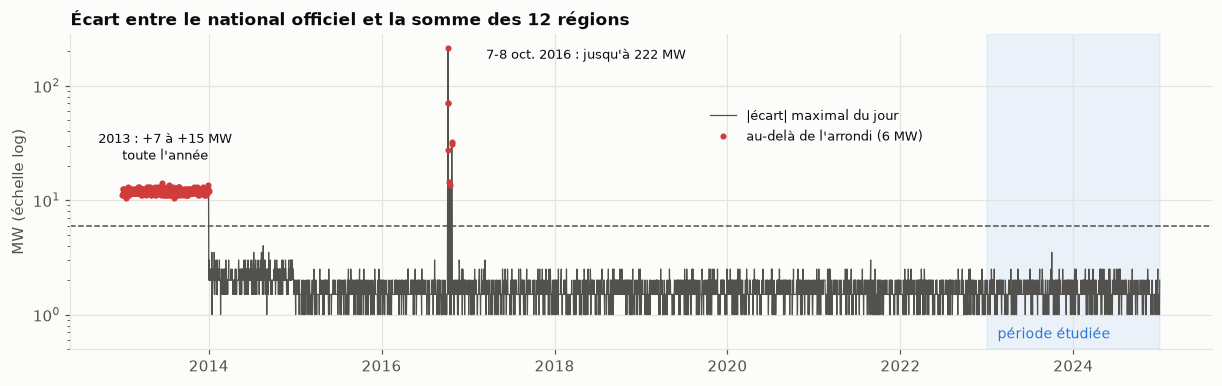

In [9]:
daily = gap.abs().resample("D").max().clip(lower=0.5)
out = daily[daily > tol]
fig, ax = plt.subplots(figsize=(11, 3.4), layout="constrained")
ax.plot(daily.index, daily.to_numpy(), lw=0.8, color=viz.TEXT_2, label="|écart| maximal du jour")
ax.plot(out.index, out.to_numpy(), "o", ms=3, color=viz.CRITICAL, label=f"au-delà de l'arrondi ({tol} MW)")
ax.axhline(tol, color=viz.TEXT_2, ls="--", lw=1)
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2025-01-01"), color=viz.BLUE, alpha=0.08)
ax.text(pd.Timestamp("2023-02-15"), 0.62, "période étudiée", color=viz.BLUE, fontsize=9)
ax.set_yscale("log"); ax.set_ylabel("MW (échelle log)")
ax.annotate("7-8 oct. 2016 : jusqu'à 222 MW", (pd.Timestamp("2016-10-07"), 215), xytext=(25, -5),
            textcoords="offset points", fontsize=8.5, va="center")
ax.annotate("2013 : +7 à +15 MW\ntoute l'année", (pd.Timestamp("2013-07-01"), 13), xytext=(0, 18),
            textcoords="offset points", fontsize=8.5, ha="center")
ax.legend(loc="upper left", bbox_to_anchor=(0.55, 0.8), fontsize=8.5)
ax.set_ylim(bottom=0.5)
ax.set_title("Écart entre le national officiel et la somme des 12 régions")
export(fig, "additivite"); plt.show()

**Conclusion du test.** H0 est **acceptée de 2014 à 2024, sauf 2016** : l'écart reste sous 6 MW (5 MW au pire,
en 2014), c'est-à-dire de l'arrondi. Deux exceptions, toutes deux hors de la période étudiée :

- **2013** : le national dépasse la somme de 7 à 15 MW **toute l'année** (environ 0,02 % de la consommation).
  C'est la signature d'une différence de périmètre, pas d'une erreur ponctuelle ;
- **7 et 8 octobre 2016** : un incident ponctuel, jusqu'à 222 MW.

Le backtest utilise 2023 et 2024 : **l'hypothèse d'additivité tient sur toute la période utilisée.**

⚠️ **Point d'attention — vérifier l'hypothèse sur la période utilisée, pas en moyenne.** Le pire écart global
(222 MW) faisait d'abord échouer le contrôle. Le regarder **année par année** montre qu'il ne concerne pas les
données du backtest. Un contrôle trop global aurait bloqué le projet, ou, pire, aurait été désactivé.

## 6. Ce qu'un modèle de base doit capturer : trois saisonnalités

La consommation électrique superpose un cycle **journalier** (24 h), un cycle **hebdomadaire** (168 h, le
week-end consomme moins) et un cycle **annuel** (le chauffage électrique en hiver).

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


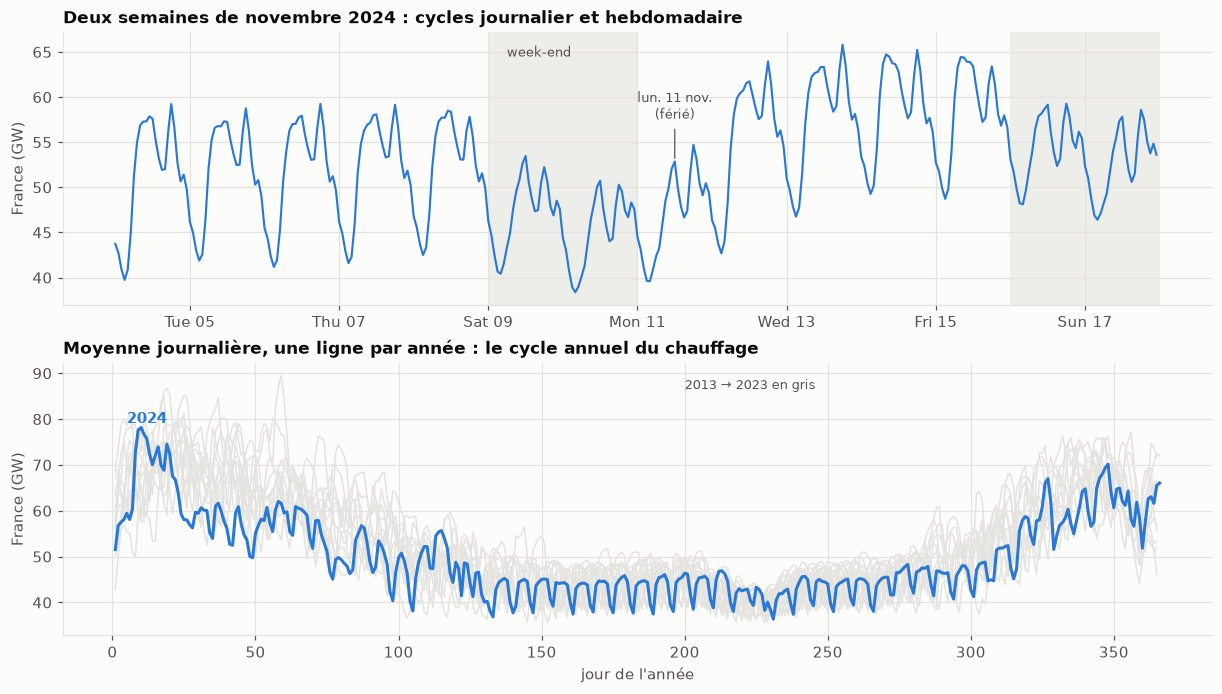

In [10]:
fr = hourly.groupby("ds")["y"].sum()
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), layout="constrained")
w = fr["2024-11-04":"2024-11-17"]
axes[0].plot(w.index, w.to_numpy() / 1000, color=viz.BLUE, lw=1.4)
for d in pd.date_range("2024-11-09", "2024-11-17", freq="7D"):
    axes[0].axvspan(d, d + pd.Timedelta(days=2), color=viz.GRID, alpha=0.6, lw=0)
axes[0].text(pd.Timestamp("2024-11-09 06:00"), w.max() / 1000 * 0.98, "week-end", fontsize=8.5, color=viz.TEXT_2)
axes[0].annotate("lun. 11 nov.\n(férié)", (pd.Timestamp("2024-11-11 12:00"), fr["2024-11-11 12:00"] / 1000),
                 xytext=(0, 28), textcoords="offset points", ha="center", fontsize=8.5, color=viz.TEXT_2,
                 arrowprops={"arrowstyle": "-", "color": viz.TEXT_2, "lw": 0.8})
axes[0].set_title("Deux semaines de novembre 2024 : cycles journalier et hebdomadaire")
axes[0].set_ylabel("France (GW)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

d = fr.resample("D").mean()
for year, g in d.groupby(d.index.year):
    color, lw, z = (viz.BLUE, 2, 3) if year == 2024 else (viz.GRID, 1, 1)
    axes[1].plot(g.index.dayofyear, g.to_numpy() / 1000, color=color, lw=lw, zorder=z)
axes[1].text(5, d[d.index.year == 2024].max() / 1000 + 1, "2024", color=viz.BLUE, fontweight="semibold")
axes[1].text(200, d.max() / 1000 - 3, "2013 → 2023 en gris", color=viz.TEXT_2, fontsize=8.5)
axes[1].set_title("Moyenne journalière, une ligne par année : le cycle annuel du chauffage")
axes[1].set_xlabel("jour de l'année"); axes[1].set_ylabel("France (GW)")
export(fig, "saisonnalites"); plt.show()

💡 **Ce que cela implique pour les modèles de base (notebook 02).**

- **SeasonalNaive(168)** répète la semaine précédente : il capture les cycles journalier et hebdomadaire, mais
  aucune tendance ni aucun effet météo.
- **MSTL** décompose la série en tendance + saisonnalité 24 h + saisonnalité 168 h + reste, et prévoit la
  tendance avec un modèle ETS. Le cycle annuel est absorbé par la tendance, sur une fenêtre de 52 semaines.
- **Aucun des deux ne connaît la température ni le calendrier des jours fériés.** Or l'hiver montre une
  consommation très variable d'un jour à l'autre (la thermosensibilité), et un lundi férié ressemble à un
  dimanche. Les grosses erreurs viendront de là (notebook 03, § 4).

## 7. Pourquoi MinT a quelque chose à exploiter : les régions bougent ensemble

MinT ne s'intéresse pas à la corrélation des **niveaux** (toutes les régions ont le même cycle journalier,
leur corrélation est trivialement forte), mais à celle des **erreurs** de prévision. Avant de prévoir, on peut
en avoir un avant-goût : la variation d'une semaine sur l'autre, `y_t − y_{t−168}`, est exactement l'erreur du
naïf saisonnier.

corrélation moyenne entre régions — niveaux : 0.91 ; erreurs du naïf saisonnier : 0.73


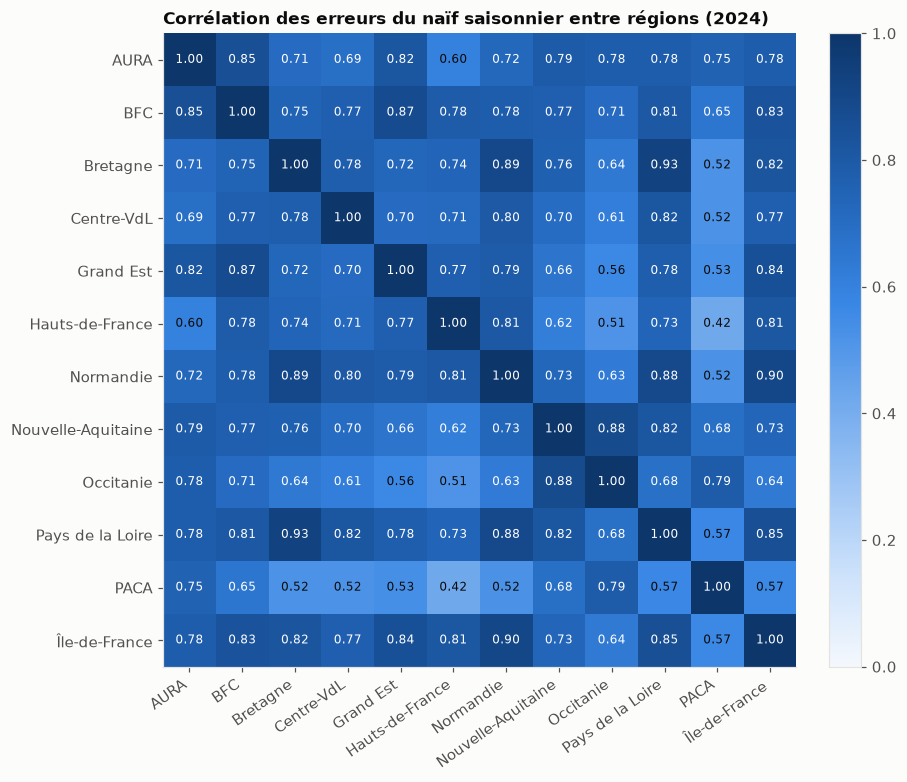

In [11]:
wide = hourly[hourly["ds"].dt.year == 2024].pivot(index="ds", columns="region", values="y")
lev = wide.corr().to_numpy()
dif = wide.diff(168).dropna().corr()
off = ~np.eye(12, dtype=bool)
print(f"corrélation moyenne entre régions — niveaux : {lev[off].mean():.2f} ; "
      f"erreurs du naïf saisonnier : {dif.to_numpy()[off].mean():.2f}")
fig, ax = plt.subplots(figsize=(8.5, 7), layout="constrained")
short = [r.replace("Provence-Alpes-Côte d'Azur", "PACA").replace("Auvergne-Rhône-Alpes", "AURA")
         .replace("Bourgogne-Franche-Comté", "BFC").replace("Centre-Val de Loire", "Centre-VdL") for r in dif.columns]
viz.heatmap(ax, dif.to_numpy(), short, title="Corrélation des erreurs du naïf saisonnier entre régions (2024)",
            fmt="{:.2f}", vmax=1)
export(fig, "correlation_erreurs_naif"); plt.show()

Les erreurs sont **fortement et positivement corrélées** d'une région à l'autre. C'est logique : une vague de
froid, un jour férié ou un pont touchent tout le pays en même temps. Deux conséquences :

1. l'erreur du total France n'est pas « 12 erreurs indépendantes qui se compensent » : elles s'additionnent
   en grande partie. Le total n'est donc pas beaucoup plus facile à prévoir que la somme de ses parties ;
2. c'est l'information que MinT peut exploiter avec une W **pleine**, et que `ols`, `wls_struct` et `wls_var`
   ignorent (W diagonale ou identité).

📌 **À retenir — les données.**
- Les données sont tracées (manifeste + sha256) et la période est figée : **données définitives, 2013 → 2024**.
- La source a un **défaut de changement d'heure** systématique : 2 doublons en mars, 1 heure manquante en
  octobre, chaque année, dans chaque région. Il est corrigé, et chaque correction est comptée.
- 🔬 **L'additivité tient** sur la période étudiée (écart ≤ 4 MW en 2023-2024, l'arrondi). Le total France = Σ 12 régions
  est donc légitime.
- Les erreurs des régions sont **corrélées** : c'est ce que MinT peut exploiter.